In [1]:
# Grid Search
# 머신러닝 모델의 “최적의 설정값(=하이퍼파라미터)”을 찾는 방법
# 쉽게 말하면,
# 	이 모델을 가장 잘 작동하게 만드는 설정 조합을 자동으로 찾아주는 도구

# 하이퍼파라미터란?
# 모델을 만들 때 사람이 직접 정해야 하는 설정값

# 그값을 수시로 수치를 변경하며 확인하기엔 너무 많다! 그래서 사용하는 게 Grid Search
# from sklearn.model_selection import GridSearchCV
# from sklearn.tree import DecisionTreeClassifier

# # 1. 모델 준비
# model = DecisionTreeClassifier()

# # 2. 탐색할 하이퍼 파라미터 후보의 값 설정
# param_grid = {
#     'max_depth': [3, 5, 7],
#     'min_samples_split': [2, 10, 20]
# }

# # 3. Grid Search 실행 (교차검증 포함?)
# grid_search = GridSearchCV(model, param_grid, cv=5)
# grid_search.fit(X_train, y_train)

# # 4. 가장 좋은 설정값과 점수 출력, 가장 좋은 모델 부르기
# print("최적 하이퍼 파라미터:", grid_search.best_params_)
# print("최고 정확도:", grid_search.best_score_)
# best_model = grid_search.best_estimator_

#### 데이터 불러오기

In [2]:
import pandas as pd
df = pd.read_csv("C:\김지은\파이썬_src\pandas-data-analysis\part7\data\San-Francisco-Crime.csv")

df.head()

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Playdata2\AppData\Local\Temp\ipykernel_10572\3894370419.py:2: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv("C:\김지은\파이썬_src\pandas-data-analysis\part7\data\San-Francisco-Crime.csv")


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541


#### 데이터 조회

In [3]:
df.shape

(878049, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878049 entries, 0 to 878048
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Dates       878049 non-null  object 
 1   Category    878049 non-null  object 
 2   Descript    878049 non-null  object 
 3   DayOfWeek   878049 non-null  object 
 4   PdDistrict  878049 non-null  object 
 5   Resolution  878049 non-null  object 
 6   Address     878049 non-null  object 
 7   X           878049 non-null  float64
 8   Y           878049 non-null  float64
dtypes: float64(2), object(7)
memory usage: 60.3+ MB


In [5]:
# # Domain 지식   컬럼정보
# Dates: 범죄 사건이 발생한 날짜와 시간 (타임스탬프)

# Category: 범죄 사건의 유형 ( 예측해야 할 목표 변수)

# Descript: 범죄 사건에 대한 상세한 설명

# DayOfWeek: 요일

# PdDistrict: 경찰서 관할 구역명

# Resolution: 사건이 어떻게 해결되었는지에 대한 정보

# Address: 범죄 사건이 발생한 대략적인 주소

# X: 경도 (Longitude)

# Y: 위도 (Latitude)

#### 데이터 전처리

In [6]:
# 불필요한 컬럼제거
train = df.drop(columns=['Descript','Resolution','Address'])
train.head()

,Dates,Category,DayOfWeek,PdDistrict,X,Y
0,2015-05-13 23:53:00,WARRANTS,Wednesday,NORTHERN,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,Wednesday,NORTHERN,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,Wednesday,NORTHERN,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,Wednesday,NORTHERN,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,Wednesday,PARK,-122.438738,37.771541


범주형 데이터 변환 ^

In [7]:
# 종속변수 범죄사건 유형 Category 인코딩
from sklearn.preprocessing import LabelEncoder
LabelEncoder().fit_transform(train.Category)
train.head()

,Dates,Category,DayOfWeek,PdDistrict,X,Y
0,2015-05-13 23:53:00,WARRANTS,Wednesday,NORTHERN,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,Wednesday,NORTHERN,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,Wednesday,NORTHERN,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,Wednesday,NORTHERN,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,Wednesday,PARK,-122.438738,37.771541


In [8]:
# 경찰서 관할 구역 PdDistrict - oneHot
district_dummies = pd.get_dummies(train.PdDistrict,prefix='District')

# 합치기
train = pd.concat([train,district_dummies],axis=1) # ^ concat 기능
                                                   # pd.concat()은 여러 개의 Series나 DataFrame을
                                                   # 위아래(row 방향) 또는 옆으로(column 방향) 합칠 때 사용한다.
train = train.drop(columns=['PdDistrict'])
train.head()

,Dates,Category,DayOfWeek,X,Y,District_BAYVIEW,District_CENTRAL,District_INGLESIDE,District_MISSION,District_NORTHERN,District_PARK,District_RICHMOND,District_SOUTHERN,District_TARAVAL,District_TENDERLOIN
0,2015-05-13 23:53:00,WARRANTS,Wednesday,-122.425892,37.774599,False,False,False,False,True,False,False,False,False,False
1,2015-05-13 23:53:00,OTHER OFFENSES,Wednesday,-122.425892,37.774599,False,False,False,False,True,False,False,False,False,False
2,2015-05-13 23:33:00,OTHER OFFENSES,Wednesday,-122.424363,37.800414,False,False,False,False,True,False,False,False,False,False
3,2015-05-13 23:30:00,LARCENY/THEFT,Wednesday,-122.426995,37.800873,False,False,False,False,True,False,False,False,False,False
4,2015-05-13 23:30:00,LARCENY/THEFT,Wednesday,-122.438738,37.771541,False,False,False,False,False,True,False,False,False,False


In [9]:
train['Year'] = pd.to_datetime(train.Dates).dt.year
train['Month'] = pd.to_datetime(train.Dates).dt.month
train['Day'] = pd.to_datetime(train.Dates).dt.day
train['Hour'] = pd.to_datetime(train.Dates).dt.hour
train['Minute'] = pd.to_datetime(train.Dates).dt.minute

train = train.drop(columns=['Dates'])

# 요일 정보
# one hot
dayofweek_onehot = pd.get_dummies(train.DayOfWeek,prefix='Day').astype(int)
pd.concat([train,dayofweek_onehot],axis=1)
train = train.drop(columns=['DayOfWeek'])

#### 훈련데이터 분리

In [10]:
from sklearn.model_selection import train_test_split
X = train.drop(columns=['Category']).to_numpy()
y = train.Category

x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,train_size=0.2,random_state=42)
# 그외에도 교차검증 방법이 있다. ^

x_train.shape, y_train.shape

y_train.value_counts()

Category
LARCENY/THEFT                  34980
OTHER OFFENSES                 25236
NON-CRIMINAL                   18461
ASSAULT                        15375
DRUG/NARCOTIC                  10794
VEHICLE THEFT                  10756
VANDALISM                       8945
WARRANTS                        8443
BURGLARY                        7351
SUSPICIOUS OCC                  6283
MISSING PERSON                  5198
ROBBERY                         4600
FRAUD                           3336
FORGERY/COUNTERFEITING          2122
SECONDARY CODES                 1997
WEAPON LAWS                     1711
PROSTITUTION                    1497
TRESPASS                        1465
STOLEN PROPERTY                  908
SEX OFFENSES FORCIBLE            877
DISORDERLY CONDUCT               864
DRUNKENNESS                      856
RECOVERED VEHICLE                627
KIDNAPPING                       468
DRIVING UNDER THE INFLUENCE      454
RUNAWAY                          389
LIQUOR LAWS                  

#### 모델 생성 및 학습

In [11]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier() # 과적합 가능성이 크다

# 모델 학습
model.fit(x_train,y_train)

# 평가 정확도
model.score(x_test,y_test)

0.18495814589146403

In [12]:
# 하이퍼 파라메터 튜닝
from sklearn.model_selection import GridSearchCV
param_grid = { # 딕셔너리 형태로 설정을 저장
   'max_depth':[3,5,7,10,15],
   'min_samples_split' : [2,10,20],  # 노드를 분할하기위한 최소 샘플수(복잡도 제어)
   'min_samples_leaf' : [1,5,10], # 리프노드를 나누기 위한 최소 샘플수
   'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV( 
    DecisionTreeClassifier(), # 모델은 학습되지않은 모델을 넣는 게 좋다.
    param_grid=param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1  # 모든 cpu코어 사용 ^
 )
grid_search.fit(x_train,y_train)

c:\김지은\파이썬_src\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


# ^

In [13]:
# 최적의 하이퍼 파라메터 값과 점수 조회
grid_search.best_params_, grid_search.best_score_

({'criterion': 'gini',
  'max_depth': 10,
  'min_samples_leaf': 1,
  'min_samples_split': 20},
 np.float64(0.265880425675742))

In [14]:
# ^^
results = pd.DataFrame(grid_search.cv_results_)
# grid_search.cv_results_ ^
# 그리드서치가 탐색한 모든 하이퍼파라미터 조합별 성능 기록표
# 를 데이터 프레임으로 변환하여 저장

results = results.sort_values(by = 'rank_test_score')
# 'rank_test_score'는 mean_test_score 기준으로 성능 순위를 매긴 값이에요.
# 1이 최고 성능을 의미하고, 숫자가 커질수록 성능이 낮은 조합이에요.

results = results[[
    'params',
    'mean_train_score',
    'mean_test_score',
    'rank_test_score'
]]
# DataFrame에서 필요한 컬럼만 선택해서 새로운 DataFrame을 만드는 것.
# 선택한 컬럼 의미
# 'params' → 사용한 하이퍼파라미터 조합
# 'mean_train_score' → 훈련 데이터에서의 평균 점수
# 'mean_test_score' → 검증 데이터에서의 평균 점수
# 'rank_test_score' → 검증 점수 기준 순위

print('GridSearchCV 결과')
results.head()

GridSearchCV 결과


,params,mean_train_score,mean_test_score,rank_test_score
29,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.284917,0.265880,1
33,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.284557,0.265863,2
35,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.284557,0.265863,2
28,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.285714,0.265852,4
34,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.284560,0.265846,5


#### best model 성능 확인

In [15]:
from sklearn.metrics import classification_report
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
print( classification_report(y_test,y_pred)  )

c:\김지은\파이썬_src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\김지은\파이썬_src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                             precision    recall  f1-score   support

                      ARSON       0.00      0.00      0.00      1210
                    ASSAULT       0.15      0.06      0.08     61501
                 BAD CHECKS       0.00      0.00      0.00       325
                    BRIBERY       0.00      0.00      0.00       231
                   BURGLARY       0.12      0.01      0.01     29404
         DISORDERLY CONDUCT       0.22      0.04      0.07      3456
DRIVING UNDER THE INFLUENCE       0.00      0.00      0.00      1814
              DRUG/NARCOTIC       0.31      0.36      0.33     43177
                DRUNKENNESS       0.00      0.00      0.00      3424
               EMBEZZLEMENT       0.00      0.00      0.00       933
                  EXTORTION       0.00      0.00      0.00       205
            FAMILY OFFENSES       0.00      0.00      0.00       393
     FORGERY/COUNTERFEITING       0.12      0.00      0.00      8487
                      FRAUD      

c:\김지은\파이썬_src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### 가중치 조절
```
클래스 불균형이 심한경우, 소수의 클래스에 가중치를 부여
사이킷런 계열은 대부분 class_weight 존재
```

In [16]:
best_params = grid_search.best_params_
best_params['class_weight'] = 'balanced'
balanced_tree = DecisionTreeClassifier(**best_params)
balanced_tree.fit(x_train,y_train)
y_pred = balanced_tree.predict(x_test)
print( classification_report(y_test,y_pred)  )

c:\김지은\파이썬_src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\김지은\파이썬_src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                             precision    recall  f1-score   support

                      ARSON       0.01      0.04      0.02      1210
                    ASSAULT       0.22      0.00      0.00     61501
                 BAD CHECKS       0.00      0.31      0.00       325
                    BRIBERY       0.00      0.03      0.00       231
                   BURGLARY       0.11      0.01      0.02     29404
         DISORDERLY CONDUCT       0.03      0.09      0.05      3456
DRIVING UNDER THE INFLUENCE       0.02      0.20      0.03      1814
              DRUG/NARCOTIC       0.25      0.34      0.29     43177
                DRUNKENNESS       0.02      0.15      0.03      3424
               EMBEZZLEMENT       0.01      0.16      0.01       933
                  EXTORTION       0.00      0.02      0.00       205
            FAMILY OFFENSES       0.00      0.19      0.00       393
     FORGERY/COUNTERFEITING       0.02      0.00      0.01      8487
                      FRAUD      

c:\김지은\파이썬_src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
# 가중치 조절을 했음에도 성능이 오르지 않음,
# 이제 모델 선에서 클래스 불균형을 해결하는 방법이 아닌
# 데이터 선에서 클래스 불균형을 해결하는 방법을 실행 : 데이터 증강, SMOTE 사용

#### 데이터 증강

In [19]:
# %pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
smote =  SMOTE(random_state=42,k_neighbors=4)
# 훈련데이터에 대해서만 적용
x_train_over, y_train_over =  smote.fit_resample(x_train,y_train)
y_train_over.value_counts()

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 5, n_samples_fit = 4, n_samples = 4

In [ ]:
# best_params 재사용
over_tree = DecisionTreeClassifier(**best_params)
over_tree.fit(x_train_over, y_train_over)
over_tree.score(x_test,y_test)

NameError: name 'x_train_over' is not defined

Dates         0.0
Category      0.0
Descript      0.0
DayOfWeek     0.0
PdDistrict    0.0
Resolution    0.0
Address       0.0
X             0.0
Y             0.0
dtype: float64


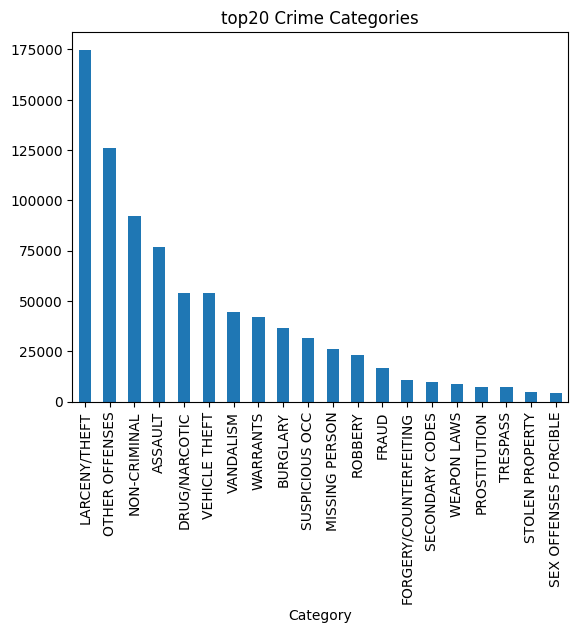

Text(0.5, 1.0, 'crim by District')

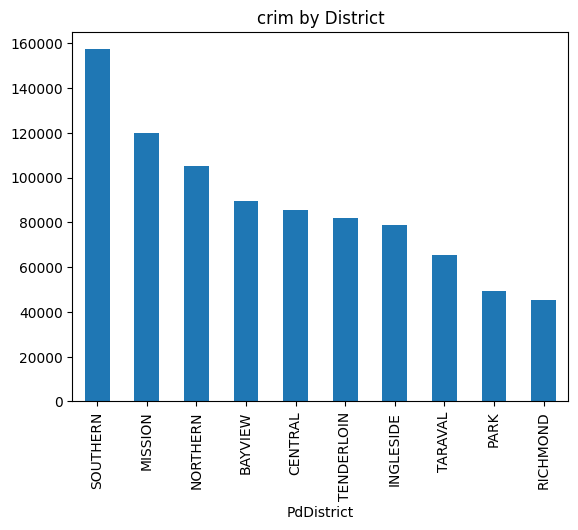

In [ ]:
# EDA
import matplotlib.pyplot as plt
import pandas as pd
url = 'C:\\김지은\\파이썬_src\\pandas-data-analysis\\part7\\data\\San-Francisco-Crime.csv'
df = pd.read_csv(url)
print(df.isna().mean().sort_values(ascending=False))

# top categories
df.Category.value_counts().head(20).plot(kind='bar')
plt.title('top20 Crime Categories')
plt.show()

# 월별 트렌드
dt = pd.to_datetime(df.Dates)
monthly = df.groupby([dt.dt.to_period('M')]).size().rename('count').to_timestamp()
monthly.plot()
plt.title('crime per month')

# 시간대
dt.dt.hour.value_counts().sort_index().plot(kind='bar')
plt.title('crime per hour')  

# Distict counts
df.PdDistrict.value_counts().plot(kind='bar')
plt.title('crim by District')

In [ ]:
# Feature Engineering ^
# 모델 성능을 높이기 위해 기존 데이터를 분석하고, 새로운 피처(특징)를 만들어 내는 과정
# 원본 데이터를 그대로 넣지 않고, 모델이 잘 이해할 수 있도록 변환/추가하는 작업

# to_datetime ^
# 문자열, 숫자, 또는 다른 형식으로 되어 있는 데이터를 datetime 타입으로 변환

# int16 이나 int8 과같은 속성들이 무엇을 의미하는지 ^

In [ ]:
# 특정 지역으로 부터 얼마나 떨어져 있는 지 수치화

# str.contains() ^
# 판다스(Pandas)에서 문자열 컬럼을 다룰 때 특정 문자열이 포함되어 있는지 확인
# 옵션	기본값	기능
# case	True	대소문자 구분 여부
# regex	True	정규표현식으로 해석할지 여부
    # 정규표현식(Regex) 기본 개념
    # 정규표현식(Regular Expression, Regex) = 문자열 안에서 패턴(규칙)을 정의하고, 그 패턴과 일치하는 문자열을 찾거나 치환하는 방법

    # 즉, “문자열의 형식을 규칙으로 표현”하는 언어
    # 단순 포함 여부('abc' in text)보다 훨씬 강력하게 문자열 검색/검증 가능

    # 기본 문법
    # 기호	의미	예시
    # .	임의의 한 문자	a.c → abc, a1c 등
    # ^	문자열 시작	^A → "A"로 시작하는 문자열
    # $	문자열 끝	e$ → "e"로 끝나는 문자열
    # *	0회 이상 반복	ab* → a, ab, abb, abbb 등
    # +	1회 이상 반복	ab+ → ab, abb, abbb 등
    # ?	0 또는 1회	ab? → a 또는 ab
    # `	`	OR (또는)
    # \d	숫자	\d → 0~9
    # \D	숫자가 아닌 문자	\D → 숫자 제외 문자
    # \s	공백 문자	\s → 스페이스, 탭 등
    # \w	알파벳/숫자/언더바	\w → a~z, A~Z, 0~9, _
# .astype()	없음	Boolean → int, str 등 데이터 타입 변환